# Distributed Dynamic IR-Drop Decomposition Analysis

This notebook performs dynamic IR-drop analysis on a multi-tile PDN netlist using the
**distributed DDM (Domain Decomposition Method) solver** with a Ray compute backend.

The distributed solver decomposes the power grid into tiles, each solved independently,
coupled through a Schur complement interface system. This enables scaling to large designs
that exceed the memory or compute capacity of a single-node flat solver.

## Analysis Flow

1. Load pre-parsed distributed tile data and create the distributed model with Ray workers
2. Run transient RC simulation to identify worst-case instances (highest peak IR-drop)
3. For each worst instance, run **adjoint sensitivity analysis** to decompose IR-drop:
   - **Static adjoint**: Uses steady-state G^{-1} sensitivity (fast, single solve)
   - **Dynamic adjoint**: Backward sweep through RC memory (captures time-varying effects)
4. Visualize and compare the static vs dynamic attribution results

Unlike the flat notebook which uses near/far spatial window decomposition via multi-RHS
transient solves, this notebook uses adjoint sensitivity analysis -- the superior method
for identifying individual aggressor contributions to a victim's IR-drop.

## Setup and Imports

In [1]:
import sys
import os
import time as time_module
import logging
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Change to project root so TileConfig relative paths resolve correctly
os.chdir(Path(__file__).parent.parent if '__file__' in dir() else Path('..'))

# Import distributed solver modules
from distributed import (
    load_distributed_partitions,
    create_distributed_model,
    DistributedDDMSolver,
)
from analysis.adjoint_sensitivity import AdjointAttribution, AggressorContribution

# Enable logging so solver progress messages are visible
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',
    force=True,
)

print(f"Working directory: {os.getcwd()}")
print("Imports successful!")

Working directory: /wv/bwdev1/patrasej/dev/sigma_dvd/prototype/.trees/ir-decomp
Imports successful!


## Configuration

Set the analysis parameters here:

In [ ]:
# ==========================================
# CONFIGURATION - Modify these parameters
# ==========================================

# Netlist path (pre-parsed distributed pkl directory)
NETLIST_DIR = Path('/home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled')
PKL_DIR = NETLIST_DIR / 'distributed_pkl'

# Time parameters
T_START = 0.0           # Start time (seconds)
T_END = 1e-9            # End time (seconds) - 1 ns
DT = 0.01e-9            # Time step (seconds) - 10 ps

# Analysis parameters
TOP_K = 2               # Number of worst instances to analyze
WINDOW_PERCENT = 10.0   # Window size as percentage of design (for spatial separation)
INTEGRATION_METHOD = 'be'  # 'trap' (Trapezoidal) or 'be' (Backward Euler)

# Adjoint analysis parameters
ADJOINT_TOP_K = 10          # Number of top aggressors to report per victim
ADJOINT_MEMORY_WINDOW = 20  # Number of time steps to look back in dynamic adjoint

# Verbose output
VERBOSE = True

print("Configuration:")
print(f"  PKL dir: {PKL_DIR}")
print(f"  Time: {T_START*1e9:.2f} ns to {T_END*1e9:.2f} ns, dt={DT*1e9:.3f} ns")
print(f"  Top-K instances: {TOP_K}")
print(f"  Window: {WINDOW_PERCENT}%")
print(f"  Integration: {INTEGRATION_METHOD}")
print(f"  Adjoint Top-K: {ADJOINT_TOP_K}")
print(f"  Adjoint memory window: {ADJOINT_MEMORY_WINDOW} steps")

## Helper Functions

In [3]:
def parse_node_coordinates(node_name: str) -> Tuple[Optional[float], Optional[float]]:
    """Extract (x, y) coordinates from node name.

    Node name format: <x>_<y>_<layer> (e.g., "1000_2000_M1")
    """
    parts = str(node_name).split('_')
    if len(parts) >= 2:
        try:
            x = float(parts[0])
            y = float(parts[1])
            return (x, y)
        except ValueError:
            pass
    return (None, None)


def extract_instance_locations_from_peaks(
    peak_data: Dict[str, Tuple[float, float]],
) -> Tuple[Dict[str, Tuple[float, float]], Tuple[float, float, float, float]]:
    """Extract (x, y) for each node from peak data using node name parsing.

    The distributed solver does not expose a flat graph with instance source
    objects, so we extract coordinates from the node names directly.

    Args:
        peak_data: Dict mapping node -> (peak_drop, peak_time) from as_flat().

    Returns:
        Tuple of:
        - node_coords: Dict mapping node name to (x, y) tuple
        - grid_bounds: (x_min, x_max, y_min, y_max) bounding box
    """
    node_coords: Dict[str, Tuple[float, float]] = {}

    for node in peak_data:
        x, y = parse_node_coordinates(node)
        if x is not None and y is not None:
            node_coords[node] = (float(x), float(y))

    # Compute grid bounds
    if node_coords:
        xs = [c[0] for c in node_coords.values()]
        ys = [c[1] for c in node_coords.values()]
        grid_bounds = (min(xs), max(xs), min(ys), max(ys))
    else:
        grid_bounds = (0.0, 1.0, 0.0, 1.0)

    return node_coords, grid_bounds


def find_worst_nodes_separated(
    peak_data: Dict[str, Tuple[float, float]],
    node_coords: Dict[str, Tuple[float, float]],
    grid_bounds: Tuple[float, float, float, float],
    top_k: int,
    window_percent: float = 5.0,
) -> List[Tuple[str, float, float, float, float]]:
    """Find top-K worst nodes with spatial separation.

    Uses greedy selection: picks worst node, then next worst whose
    window doesn't overlap with any already-selected window.

    Args:
        peak_data: Dict mapping node -> (peak_drop, peak_time).
        node_coords: Dict mapping node -> (x, y).
        grid_bounds: (x_min, x_max, y_min, y_max) bounding box.
        top_k: Number of worst nodes to select.
        window_percent: Window size as percentage of grid extent.

    Returns:
        List of (node, x, y, peak_drop, peak_time) tuples.
    """
    x_min_g, x_max_g, y_min_g, y_max_g = grid_bounds
    w = (x_max_g - x_min_g) * window_percent / 100.0
    h = (y_max_g - y_min_g) * window_percent / 100.0

    # Build candidates: (node, x, y, drop, time)
    candidates = []
    for node, (drop, t) in peak_data.items():
        if node in node_coords:
            x, y = node_coords[node]
            candidates.append((node, x, y, drop, t))

    # Sort by IR-drop descending
    candidates.sort(key=lambda c: c[3], reverse=True)

    selected = []
    selected_windows = []

    for node, x, y, drop, t in candidates:
        if len(selected) >= top_k:
            break

        win = (x - w / 2, x + w / 2, y - h / 2, y + h / 2)
        overlaps = any(
            not (win[1] < sw[0] or sw[1] < win[0] or win[3] < sw[2] or sw[3] < win[2])
            for sw in selected_windows
        )

        if not overlaps:
            selected.append((node, x, y, drop, t))
            selected_windows.append(win)

    return selected


print("Helper functions defined.")

Helper functions defined.


## Load Distributed Model

Load the pre-parsed tile data and create the distributed model with Ray workers.
Each tile gets its own worker that holds the local block matrix system.

In [4]:
timings = {}
t0 = time_module.perf_counter()

print(f"Loading distributed partitions from: {PKL_DIR}")
bundle = load_distributed_partitions(str(PKL_DIR))

print(f"Creating distributed model with Ray backend...")
model = create_distributed_model(bundle, backend='ray')
solver = DistributedDDMSolver(model)

timings['load_model'] = time_module.perf_counter() - t0

print(f"\nDistributed model created in {timings['load_model']:.2f}s")
print(f"  Net: {model.net_name}")
print(f"  Vdd: {model.vdd} V")
print(f"  Tiles: {model.n_tiles} ({model.tile_grid[0]}x{model.tile_grid[1]} grid)")
print(f"  Interface nodes: {len(model.interface_nodes)}")
print(f"  Pad nodes: {len(model.pad_nodes)}")

# Print per-tile summary
total_interior = sum(model.tile_interior_counts.values())
total_boundary = sum(len(bl) for bl in model.tile_boundary_nodes.values())
print(f"  Total interior nodes: {total_interior:,}")
print(f"  Total boundary nodes (with overlap): {total_boundary:,}")

Loaded metadata from /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl: 9 tiles, 1973 shared boundary nodes


Loading distributed partitions from: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/distributed_pkl
Creating distributed model with Ray backend...


/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-20 20:06:45,655	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-20 20:06:53,998	INFO worker.py:2013 -- Started a local Ray instance.
/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
Interface: 1996 nodes (1973 boundary + 27 die attachment)
Model created i


Distributed model created in 20.38s
  Net: VDD_XLV
  Vdd: 0.66 V
  Tiles: 9 (3x3 grid)
  Interface nodes: 1996
  Pad nodes: 1
  Total interior nodes: 133,584
  Total boundary nodes (with overlap): 3,957


## Initial Transient Solve

Run the full distributed transient simulation to identify the worst-case instances.
The solver uses:
1. **Preprocessing**: Vectorize and optionally smooth current sources on each tile worker
2. **DC factorization**: Factor G matrices and assemble Schur complement interface
3. **Transient factorization**: Factor A = G + C_coeff * C matrices
4. **Time stepping**: Implicit integration (Backward Euler or Trapezoidal) with distributed
   reduce-scatter at each step

In [ ]:
# Step 1: Preprocess current sources (vectorize, no smoothing to match flat solver)
print("Preprocessing current sources...")
t0 = time_module.perf_counter()
smoothed = solver.preprocess_sources(
    time_step=DT, t_start=T_START, t_end=T_END, smooth=False, verbose=VERBOSE,
)
timings['preprocess'] = time_module.perf_counter() - t0
print(f"  Done in {timings['preprocess']:.2f}s")

# Step 2: DC factorization (needed for transient IC)
print("\nFactoring DC system...")
t0 = time_module.perf_counter()
dc_ctx = solver.prepare(verbose=VERBOSE)
timings['prepare_dc'] = time_module.perf_counter() - t0
print(f"  Done in {timings['prepare_dc']:.2f}s")

# Step 3: Transient factorization
print(f"\nFactoring transient system (method={INTEGRATION_METHOD}, dt={DT*1e12:.1f}ps)...")
t0 = time_module.perf_counter()
trans_ctx = solver.prepare_transient(
    dt=DT, method=INTEGRATION_METHOD, verbose=VERBOSE,
)
timings['prepare_transient'] = time_module.perf_counter() - t0
print(f"  Done in {timings['prepare_transient']:.2f}s")

# Step 4: Transient solve (dc_ctx provides initial condition)
print(f"\nRunning transient solve ({T_START*1e9:.1f} ns to {T_END*1e9:.1f} ns)...")
t0 = time_module.perf_counter()
trans_result = solver.solve_transient(
    context=trans_ctx,
    dc_context=dc_ctx,
    t_start=T_START,
    t_end=T_END,
    smoothed_sources=smoothed,
    n_worst_nodes=TOP_K * 5,
    verbose=VERBOSE,
)
timings['transient_solve'] = time_module.perf_counter() - t0
print(f"  Done in {timings['transient_solve']:.2f}s")
print(f"  Peak IR-drop: {trans_result.peak_ir_drop * 1000:.3f} mV")
print(f"  Peak time: {trans_result.peak_ir_drop_time * 1e9:.3f} ns")

In [ ]:
%matplotlib inline

# Collect peak data from workers (lazy collection)
print("Collecting peak data from workers...")
t0 = time_module.perf_counter()
peak_data = trans_result.as_flat()  # Dict[str, (peak_drop, peak_time)]
timings['collect_peaks'] = time_module.perf_counter() - t0
print(f"  Collected {len(peak_data):,} nodes in {timings['collect_peaks']:.2f}s")

# Extract node coordinates from node names
node_coords, grid_bounds = extract_instance_locations_from_peaks(peak_data)
print(f"  Nodes with coordinates: {len(node_coords):,}")
print(f"  Grid bounds: X=[{grid_bounds[0]:.0f}, {grid_bounds[1]:.0f}], "
      f"Y=[{grid_bounds[2]:.0f}, {grid_bounds[3]:.0f}]")

# Find worst spatially-separated nodes (same window % as flat notebook)
worst_instances = find_worst_nodes_separated(
    peak_data, node_coords, grid_bounds, TOP_K, window_percent=WINDOW_PERCENT,
)

print(f"\nTop-{TOP_K} worst spatially-separated nodes:")
print(f"{'Rank':<5} {'Node':<30} {'X':>10} {'Y':>10} {'Peak(mV)':>10} {'Time(ns)':>10}")
print("-" * 80)
for i, (node, x, y, drop, t) in enumerate(worst_instances, 1):
    node_short = node[:28] + '...' if len(node) > 30 else node
    print(f"{i:<5} {node_short:<30} {x:>10.0f} {y:>10.0f} {drop*1000:>10.3f} {t*1e9:>10.3f}")

# Visualize instance distribution with worst-case markers
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all nodes with coordinates as background
xs_all = [c[0] for c in node_coords.values()]
ys_all = [c[1] for c in node_coords.values()]
# Color by IR-drop
drops_all = [peak_data[n][0] * 1000 for n in node_coords]  # mV
sc = ax.scatter(xs_all, ys_all, c=drops_all, s=1, alpha=0.5, cmap='hot_r')
plt.colorbar(sc, ax=ax, label='Peak IR-Drop (mV)', shrink=0.8)

# Mark worst instances
for i, (node, x, y, drop, t) in enumerate(worst_instances, 1):
    ax.plot(x, y, 'o', markersize=14, markerfacecolor='none',
            markeredgecolor='blue', markeredgewidth=2)
    ax.annotate(f'#{i}\n{drop*1000:.1f}mV', (x, y),
                textcoords='offset points', xytext=(10, 10),
                fontsize=8, color='blue', fontweight='bold')

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Peak IR-Drop Distribution ({model.net_name})\n'
             f'{len(node_coords):,} nodes, peak={trans_result.peak_ir_drop*1000:.2f} mV')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Adjoint Sensitivity Analysis

For each worst-case node, we identify the **top aggressor current sources** that
contribute most to its IR-drop using adjoint sensitivity.

Two complementary methods are compared:

- **Static adjoint** (`analyze_adjoint_static`): Uses the steady-state sensitivity
  matrix G^{-1}. Answers: *"If this source were always on, how much would it affect
  the victim?"* Fast (reuses DC factorization) but ignores RC time constants.

- **Dynamic adjoint** (`analyze_adjoint`): Propagates sensitivities backward through
  the RC network's memory window. Answers: *"Given the actual time-varying currents,
  which sources contributed most to the IR-drop at time T?"*

The adjoint approach is superior to the near/far spatial window decomposition because
it identifies **individual source contributions** rather than just aggregate spatial regions.

In [7]:
from dataclasses import dataclass as _dc


@_dc
class AdjointComparison:
    """Holds static and dynamic adjoint results for one victim."""
    node: str
    x: float
    y: float
    peak_drop_mV: float
    peak_time_ns: float
    static_result: AdjointAttribution
    dynamic_result: AdjointAttribution


adjoint_comparisons: List[AdjointComparison] = []

for rank, (node, x, y, peak_drop, peak_time) in enumerate(worst_instances, 1):
    print(f"\n{'='*70}")
    print(f"Instance #{rank}: node={node}")
    print(f"  Location: ({x:.0f}, {y:.0f})")
    print(f"  Peak IR-drop: {peak_drop*1000:.3f} mV at t={peak_time*1e9:.3f} ns")

    observation_time = peak_time

    # --- Static adjoint ---
    print(f"\n  Running static adjoint (top-{ADJOINT_TOP_K})...")
    t0 = time_module.perf_counter()
    static_attr = solver.analyze_adjoint_static(
        victim_nodes=node,
        observation_time=observation_time,
        dc_context=dc_ctx,
        top_k=ADJOINT_TOP_K,
        include_waveforms=False,
        verbose=VERBOSE,
    )
    t_static = time_module.perf_counter() - t0
    print(f"    Done in {t_static:.2f}s")
    print(f"    IR-drop at T: {static_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {static_attr.self_contribution_mV:.3f} mV "
          f"({static_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {static_attr.attribution_efficiency:.4f}")

    # --- Dynamic adjoint ---
    print(f"\n  Running dynamic adjoint (memory_window={ADJOINT_MEMORY_WINDOW})...")
    t0 = time_module.perf_counter()
    dynamic_attr = solver.analyze_adjoint(
        victim_nodes=node,
        observation_time=observation_time,
        trans_context=trans_ctx,
        transient_result=trans_result,
        memory_window=ADJOINT_MEMORY_WINDOW,
        top_k=ADJOINT_TOP_K,
        include_waveforms=True,
        verbose=VERBOSE,
    )
    t_dynamic = time_module.perf_counter() - t0
    print(f"    Done in {t_dynamic:.2f}s")
    print(f"    IR-drop at T: {dynamic_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {dynamic_attr.self_contribution_mV:.3f} mV "
          f"({dynamic_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {dynamic_attr.attribution_efficiency:.4f}")

    adjoint_comparisons.append(AdjointComparison(
        node=node, x=x, y=y,
        peak_drop_mV=peak_drop * 1000,
        peak_time_ns=peak_time * 1e9,
        static_result=static_attr,
        dynamic_result=dynamic_attr,
    ))

print(f"\n{'='*70}")
print(f"Adjoint analysis complete for {len(adjoint_comparisons)} instances.")


Instance #1: node=1912400_2256000_M0
  Location: (1912400, 2256000)
  Peak IR-drop: 32.170 mV at t=0.400 ns

  Running static adjoint (top-10)...


Victim '1912400_2256000_M0' found in tiles: [(2, 2)]
Tile (2, 2): victim is interior (idx=2286)
Adjoint static analysis for '1912400_2256000_M0':
  IR-drop at T: 1.146 mV
  Self contribution: 11.588 mV (1010.9%)
  Top aggressor: 1902400_2256000_M0 (6.220 mV, 542.6%)
  Attribution efficiency: 48.221
  Total time: 0.422s
Victim '1912400_2256000_M0' found in tiles: [(2, 2)]
Backward sweep: 21 steps, dt=1.00e-11 s, t_start=2.00e-10 s, T=4.00e-10 s


    Done in 1.33s
    IR-drop at T: 1.146 mV
    Self-contribution: 11.588 mV (1010.9%)
    Attribution efficiency: 48.2207

  Running dynamic adjoint (memory_window=20)...


Backward step 10/20 (t=3.000e-10 s)
Backward step 20/20 (t=2.000e-10 s)
Adjoint dynamic analysis for '1912400_2256000_M0':
  IR-drop at T: 32.170 mV
  Self contribution: 11.308 mV (35.2%)
  Top aggressor: 1902400_2256000_M0 (6.017 mV, 18.7%)
  Attribution efficiency: 1.487
  Total time: 3.283s
Victim '1844000_2256000_M0' found in tiles: [(1, 2)]
Tile (1, 2): victim is interior (idx=15064)


    Done in 3.45s
    IR-drop at T: 32.170 mV
    Self-contribution: 11.308 mV (35.2%)
    Attribution efficiency: 1.4872

Instance #2: node=1844000_2256000_M0
  Location: (1844000, 2256000)
  Peak IR-drop: 31.731 mV at t=0.400 ns

  Running static adjoint (top-10)...


Adjoint static analysis for '1844000_2256000_M0':
  IR-drop at T: 1.225 mV
  Self contribution: 8.424 mV (687.7%)
  Top aggressor: 1834000_2256000_M0 (4.916 mV, 401.3%)
  Attribution efficiency: 42.860
  Total time: 0.346s
Victim '1844000_2256000_M0' found in tiles: [(1, 2)]
Backward sweep: 21 steps, dt=1.00e-11 s, t_start=2.00e-10 s, T=4.00e-10 s


    Done in 0.36s
    IR-drop at T: 1.225 mV
    Self-contribution: 8.424 mV (687.7%)
    Attribution efficiency: 42.8603

  Running dynamic adjoint (memory_window=20)...


Backward step 10/20 (t=3.000e-10 s)
Backward step 20/20 (t=2.000e-10 s)
Adjoint dynamic analysis for '1844000_2256000_M0':
  IR-drop at T: 31.731 mV
  Self contribution: 8.184 mV (25.8%)
  Top aggressor: 1834000_2256000_M0 (4.735 mV, 14.9%)
  Attribution efficiency: 1.426
  Total time: 2.535s


    Done in 2.69s
    IR-drop at T: 31.731 mV
    Self-contribution: 8.184 mV (25.8%)
    Attribution efficiency: 1.4262

Adjoint analysis complete for 2 instances.


In [8]:
# Print detailed comparison tables
for comp in adjoint_comparisons:
    s = comp.static_result
    d = comp.dynamic_result

    print(f"\n{'='*90}")
    print(f"ADJOINT COMPARISON: {comp.node}")
    print(f"  Location: ({comp.x:.0f}, {comp.y:.0f})  |  Peak: {comp.peak_drop_mV:.3f} mV at {comp.peak_time_ns:.3f} ns")
    print(f"{'='*90}")

    # Summary row
    print(f"\n  {'Metric':<30} {'Static':>15} {'Dynamic':>15} {'Diff':>12}")
    print(f"  {'-'*72}")
    print(f"  {'IR-drop at T (mV)':<30} {s.ir_drop_at_T:>15.3f} {d.ir_drop_at_T:>15.3f} "
          f"{d.ir_drop_at_T - s.ir_drop_at_T:>+12.3f}")
    print(f"  {'Self-contribution (mV)':<30} {s.self_contribution_mV:>15.3f} {d.self_contribution_mV:>15.3f} "
          f"{d.self_contribution_mV - s.self_contribution_mV:>+12.3f}")
    print(f"  {'Self-contribution (%)':<30} {s.self_contribution_pct:>15.1f} {d.self_contribution_pct:>15.1f}")
    print(f"  {'Attribution efficiency':<30} {s.attribution_efficiency:>15.4f} {d.attribution_efficiency:>15.4f}")
    print(f"  {'Total attributed (mV)':<30} {s.total_attributed_ir_drop:>15.3f} {d.total_attributed_ir_drop:>15.3f}")

    # Top aggressors side by side
    print(f"\n  TOP-{ADJOINT_TOP_K} AGGRESSORS")
    print(f"  {'Rank':<5} {'Static Node':<25} {'mV':>8} {'%':>6}   {'Dynamic Node':<25} {'mV':>8} {'%':>6}")
    print(f"  {'-'*90}")

    n_rows = max(len(s.top_aggressors), len(d.top_aggressors))
    for i in range(n_rows):
        # Static column
        if i < len(s.top_aggressors):
            sa = s.top_aggressors[i]
            s_node = str(sa.node)[:23]
            s_mv = f"{sa.contribution_mV:.3f}"
            s_pct = f"{sa.contribution_pct:.1f}"
        else:
            s_node, s_mv, s_pct = "", "", ""

        # Dynamic column
        if i < len(d.top_aggressors):
            da = d.top_aggressors[i]
            d_node = str(da.node)[:23]
            d_mv = f"{da.contribution_mV:.3f}"
            d_pct = f"{da.contribution_pct:.1f}"
        else:
            d_node, d_mv, d_pct = "", "", ""

        print(f"  {i+1:<5} {s_node:<25} {s_mv:>8} {s_pct:>6}   {d_node:<25} {d_mv:>8} {d_pct:>6}")

    # Check overlap in top-K sets
    s_nodes = {a.node for a in s.top_aggressors}
    d_nodes = {a.node for a in d.top_aggressors}
    overlap = s_nodes & d_nodes
    print(f"\n  Overlap in top-{ADJOINT_TOP_K}: {len(overlap)}/{ADJOINT_TOP_K} nodes in common")


ADJOINT COMPARISON: 1912400_2256000_M0
  Location: (1912400, 2256000)  |  Peak: 32.170 mV at 0.400 ns

  Metric                                  Static         Dynamic         Diff
  ------------------------------------------------------------------------
  IR-drop at T (mV)                        1.146          32.170      +31.024
  Self-contribution (mV)                  11.588          11.308       -0.279
  Self-contribution (%)                   1010.9            35.2
  Attribution efficiency                 48.2207          1.4872
  Total attributed (mV)                   55.277          47.842

  TOP-10 AGGRESSORS
  Rank  Static Node                     mV      %   Dynamic Node                    mV      %
  ------------------------------------------------------------------------------------------
  1     1902400_2256000_M0           6.220  542.6   1902400_2256000_M0           6.017   18.7
  2     1936600_2256000_M0           3.755  327.6   1936600_2256000_M0           3.581   1

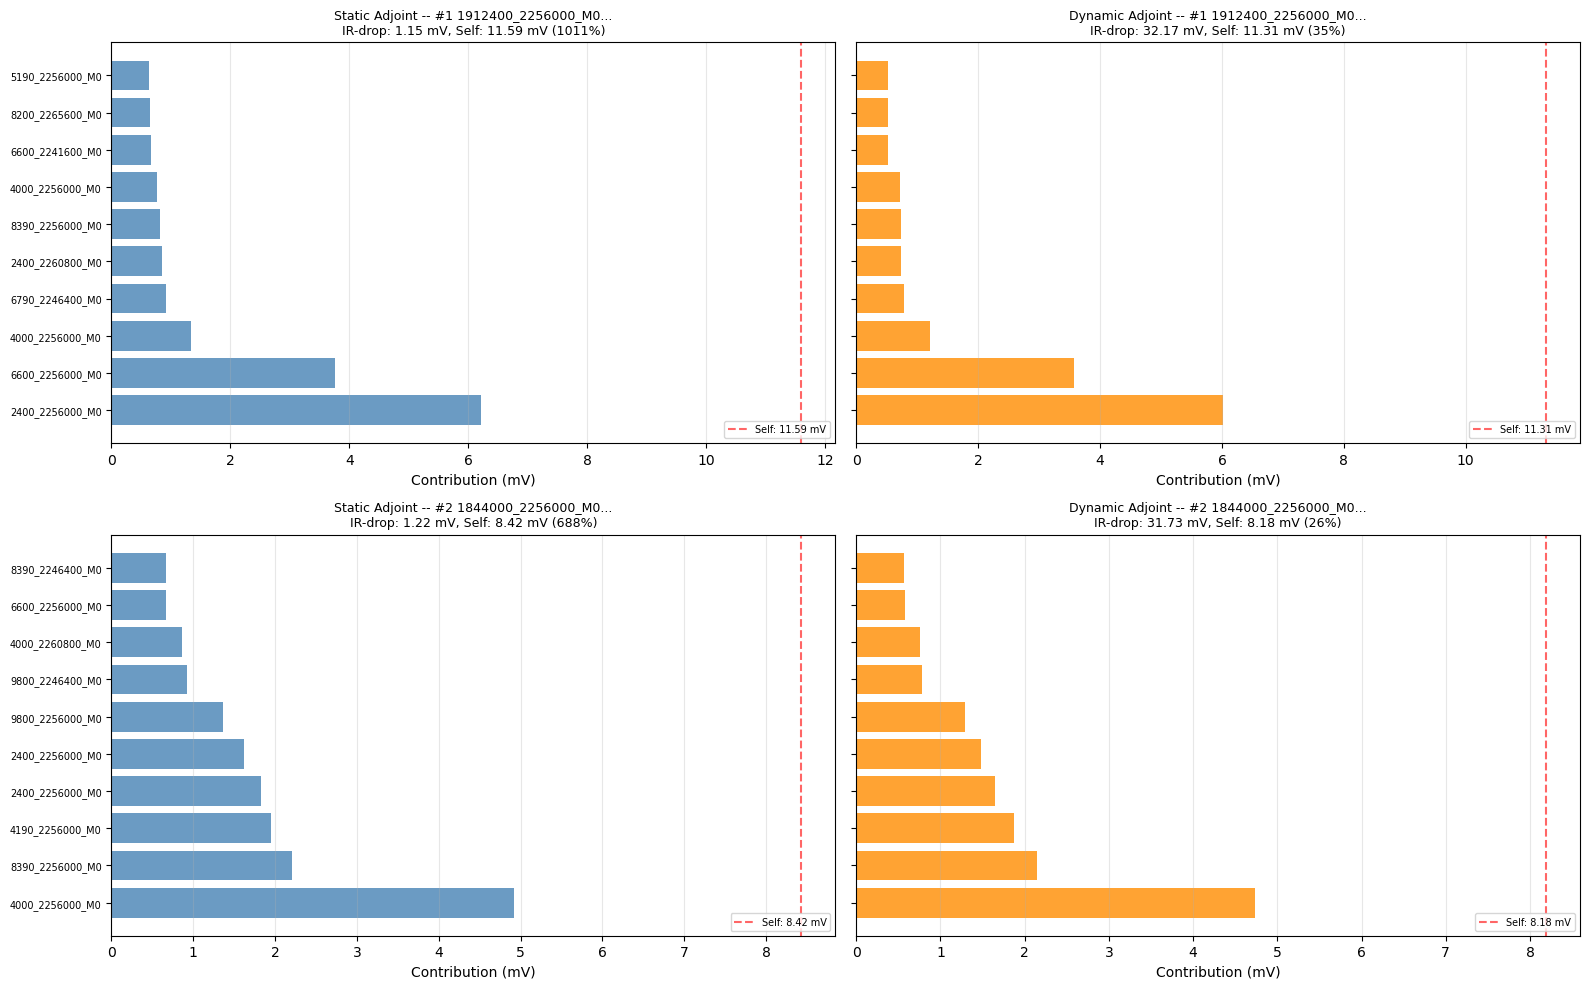

In [9]:
# Visualization: Side-by-side bar charts of top-K aggressors (static vs dynamic)
n_victims = len(adjoint_comparisons)
fig, axes = plt.subplots(n_victims, 2, figsize=(16, 5 * n_victims), sharey='row')
if n_victims == 1:
    axes = axes.reshape(1, -1)

for vi, comp in enumerate(adjoint_comparisons):
    for ci, (label, attr, color) in enumerate([
        ('Static', comp.static_result, 'steelblue'),
        ('Dynamic', comp.dynamic_result, 'darkorange'),
    ]):
        ax = axes[vi, ci]
        aggressors = attr.top_aggressors[:ADJOINT_TOP_K]
        nodes = [str(a.node)[-15:] for a in aggressors]  # last 15 chars
        contribs = [a.contribution_mV for a in aggressors]

        y_pos = np.arange(len(aggressors))
        ax.barh(y_pos, contribs, color=color, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(nodes, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('Contribution (mV)')
        ax.set_title(
            f'{label} Adjoint -- #{vi+1} {comp.node[:20]}...\n'
            f'IR-drop: {attr.ir_drop_at_T:.2f} mV, '
            f'Self: {attr.self_contribution_mV:.2f} mV ({attr.self_contribution_pct:.0f}%)',
            fontsize=9,
        )
        ax.grid(axis='x', alpha=0.3)

        # Add self-contribution marker
        if attr.self_contribution_mV > 0:
            ax.axvline(attr.self_contribution_mV, color='red', linestyle='--',
                       alpha=0.6, label=f'Self: {attr.self_contribution_mV:.2f} mV')
            ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

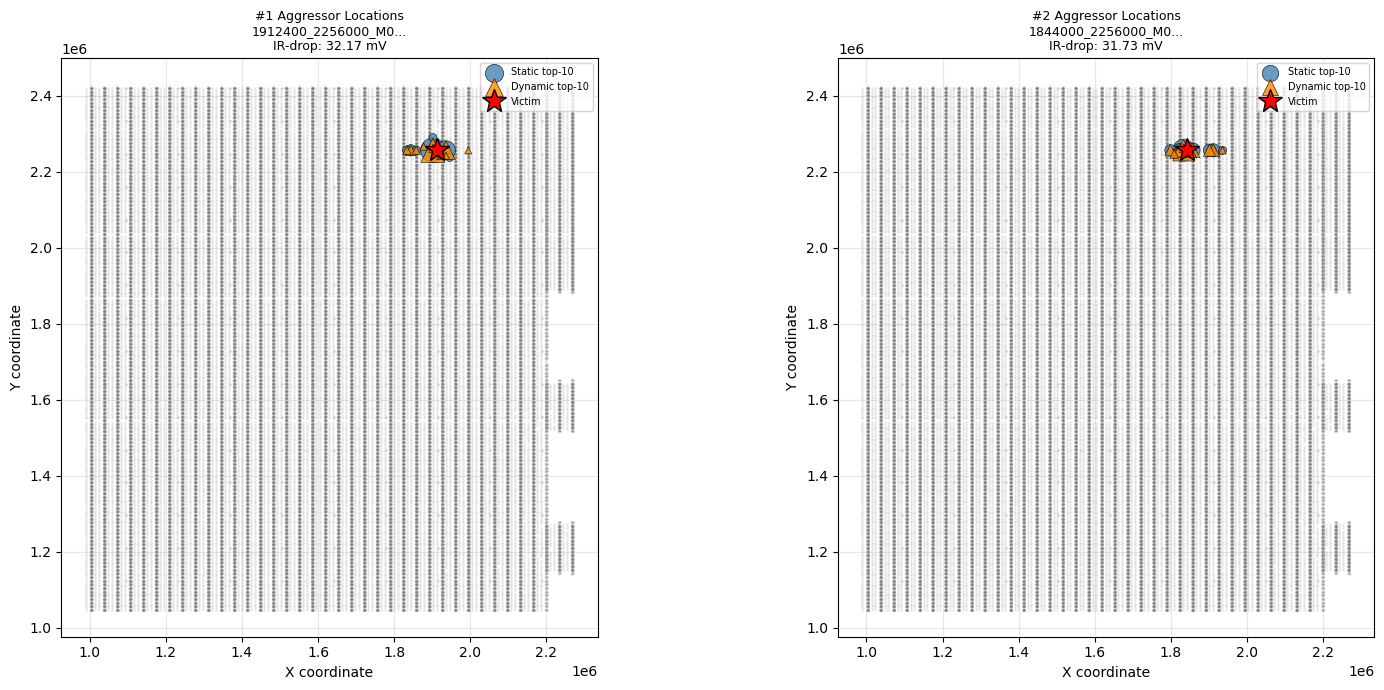

In [10]:
# Spatial map: aggressor locations for each victim
fig, axes = plt.subplots(1, n_victims, figsize=(8 * n_victims, 7))
if n_victims == 1:
    axes = [axes]

for vi, comp in enumerate(adjoint_comparisons):
    ax = axes[vi]

    # Background: all nodes in gray
    ax.scatter(xs_all, ys_all, alpha=0.1, s=1, c='gray')

    # Plot top aggressor locations for both methods
    for label, attr, marker, color in [
        ('Static', comp.static_result, 'o', 'steelblue'),
        ('Dynamic', comp.dynamic_result, '^', 'darkorange'),
    ]:
        agg_xs, agg_ys, agg_sizes = [], [], []
        for agg in attr.top_aggressors[:ADJOINT_TOP_K]:
            # Parse coordinates from the aggressor node name
            coords = parse_node_coordinates(agg.node)
            if coords[0] is not None:
                agg_xs.append(coords[0])
                agg_ys.append(coords[1])
                agg_sizes.append(max(20, abs(agg.contribution_mV) * 50))

        ax.scatter(agg_xs, agg_ys, s=agg_sizes, marker=marker, color=color,
                   edgecolors='black', linewidths=0.5, alpha=0.8,
                   label=f'{label} top-{ADJOINT_TOP_K}')

    # Mark victim
    ax.plot(comp.x, comp.y, '*', markersize=18, color='red', markeredgecolor='black',
            markeredgewidth=1, label='Victim', zorder=10)

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(
        f'#{vi+1} Aggressor Locations\n{comp.node[:35]}...\n'
        f'IR-drop: {comp.peak_drop_mV:.2f} mV',
        fontsize=9,
    )
    ax.legend(loc='upper right', fontsize=7)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Near/Far Decomposition via Adjoint Attribution

For each worst-case victim, define a spatial window (same `WINDOW_PERCENT` as the flat notebook)
and partition the **adjoint-attributed contributions** into:
- **Near**: sources inside the window around the victim
- **Far**: sources outside the window

This uses the per-source contributions from the dynamic adjoint analysis. Unlike the flat
notebook's multi-RHS approach (which runs 3 separate transient solves with masked sources),
the adjoint decomposition accounts for coupling through the grid and gives exact per-source
attribution in a single backward sweep.

In [ ]:
from distributed.tile_parsing import _parse_node_xy

def compute_window(cx: float, cy: float, bounds, pct: float):
    """Compute rectangular window centered at (cx, cy)."""
    x0, x1, y0, y1 = bounds
    w = (x1 - x0) * pct / 100.0
    h = (y1 - y0) * pct / 100.0
    return (max(x0, cx - w/2), min(x1, cx + w/2),
            max(y0, cy - h/2), min(y1, cy + h/2))

def decompose_near_far(attr, window):
    """Partition adjoint contributions into near/far by spatial window."""
    x_min, x_max, y_min, y_max = window
    near_mV, far_mV = 0.0, 0.0
    near_sources, far_sources = [], []

    # Self-contribution (victim's own sources) — always "near"
    near_mV += attr.self_contribution_mV

    for agg in attr.top_aggressors:
        x, y = _parse_node_xy(agg.node)
        if x is not None and x_min <= x <= x_max and y_min <= y <= y_max:
            near_mV += agg.contribution_mV
            near_sources.append(agg)
        else:
            far_mV += agg.contribution_mV
            far_sources.append(agg)

    # Unattributed remainder (sources beyond top-K) — distribute proportionally
    top_total = attr.self_contribution_mV + sum(a.contribution_mV for a in attr.top_aggressors)
    remainder = attr.total_attributed_ir_drop - top_total
    if near_mV + far_mV > 0:
        near_frac = near_mV / (near_mV + far_mV)
        near_mV += remainder * near_frac
        far_mV += remainder * (1 - near_frac)

    return near_mV, far_mV, len(near_sources), len(far_sources)


# Compute near/far for each victim using dynamic adjoint results
print(f"{'='*80}")
print(f"NEAR/FAR DECOMPOSITION (Window = {WINDOW_PERCENT}% of design)")
print(f"{'='*80}")
print(f"\n{'Rank':<5} {'Node':<25} {'Peak(mV)':<10} {'Near(mV)':<10} {'Far(mV)':<10} {'Near%':<7} {'Far%':<7}")
print("-" * 80)

near_far_results = []
for i, comp in enumerate(adjoint_comparisons):
    window = compute_window(comp.x, comp.y, grid_bounds, WINDOW_PERCENT)
    d = comp.dynamic_result
    near_mV, far_mV, n_near, n_far = decompose_near_far(d, window)

    total = near_mV + far_mV
    near_pct = 100.0 * near_mV / total if total > 0 else 0.0
    far_pct = 100.0 * far_mV / total if total > 0 else 0.0

    near_far_results.append({
        'node': comp.node, 'x': comp.x, 'y': comp.y,
        'window': window,
        'peak_mV': comp.peak_drop_mV,
        'near_mV': near_mV, 'far_mV': far_mV,
        'near_pct': near_pct, 'far_pct': far_pct,
        'n_near': n_near, 'n_far': n_far,
    })

    node_short = comp.node[:23] + '..' if len(comp.node) > 25 else comp.node
    print(f"{i+1:<5} {node_short:<25} {comp.peak_drop_mV:<10.3f} {near_mV:<10.3f} "
          f"{far_mV:<10.3f} {near_pct:<7.1f} {far_pct:<7.1f}")

    print(f"      Window: [{window[0]:.0f}-{window[1]:.0f}] x [{window[2]:.0f}-{window[3]:.0f}]"
          f"  Near top-K: {n_near}, Far top-K: {n_far}")

if near_far_results:
    avg_near = np.mean([r['near_pct'] for r in near_far_results])
    avg_far = np.mean([r['far_pct'] for r in near_far_results])
    print(f"\nAverage near contribution: {avg_near:.1f}%")
    print(f"Average far contribution: {avg_far:.1f}%")

In [ ]:
# Near vs Far bar chart + spatial map with windows
n_inst = len(near_far_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: stacked bar chart
ax = axes[0]
x_pos = np.arange(n_inst)
near_vals = [r['near_mV'] for r in near_far_results]
far_vals = [r['far_mV'] for r in near_far_results]
labels = [f"#{i+1}\n{r['node'][-12:]}" for i, r in enumerate(near_far_results)]

ax.bar(x_pos, near_vals, 0.5, label='Near', color='royalblue')
ax.bar(x_pos, far_vals, 0.5, bottom=near_vals, label='Far', color='coral')
for i, r in enumerate(near_far_results):
    ax.text(i, r['near_mV'] / 2, f"{r['near_pct']:.0f}%",
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if r['far_mV'] > 0.5:
        ax.text(i, r['near_mV'] + r['far_mV'] / 2, f"{r['far_pct']:.0f}%",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xlabel('Victim')
ax.set_ylabel('Attributed IR-Drop (mV)')
ax.set_title(f'Near vs Far Contributions\n(Window = {WINDOW_PERCENT}% of design)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: spatial map with analysis windows
ax = axes[1]
ax.scatter(xs_all, ys_all, alpha=0.1, s=1, c='gray')
colors_map = plt.cm.tab10(np.linspace(0, 1, n_inst))
for i, r in enumerate(near_far_results):
    wx_min, wx_max, wy_min, wy_max = r['window']
    rect = patches.Rectangle(
        (wx_min, wy_min), wx_max - wx_min, wy_max - wy_min,
        linewidth=2, edgecolor=colors_map[i], facecolor=colors_map[i], alpha=0.2,
    )
    ax.add_patch(rect)
    ax.plot(r['x'], r['y'], 'o', markersize=12, color=colors_map[i],
            label=f"#{i+1}: {r['peak_mV']:.1f} mV (Near {r['near_pct']:.0f}%)")

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Analysis Windows ({WINDOW_PERCENT}% of design)')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Static vs Dynamic Adjoint: Interpretation

- **Static adjoint** uses the steady-state sensitivity matrix G^{-1}. It answers:
  *"If this source were always on, how much would it affect the victim?"*
  Fast (single solve) but ignores RC time constants.

- **Dynamic adjoint** propagates sensitivities backward through the RC network's
  memory window. It answers: *"Given the actual time-varying currents, which sources
  contributed most to the IR-drop at time T?"*

**When the results agree** (same top aggressors, similar contributions): the RC time
constants are small relative to the current switching -- the grid responds
quasi-statically.

**When results differ**: decoupling capacitance plays a significant role. Sources that
switch near time T may rank higher in the dynamic analysis, while DC-heavy sources
rank higher in static.

## Results Summary

In [ ]:
print("=" * 80)
print("DISTRIBUTED DYNAMIC IR-DROP DECOMPOSITION ANALYSIS RESULTS")
print("=" * 80)
print(f"PKL dir: {PKL_DIR}")
print(f"Net: {model.net_name}")
print(f"Vdd: {model.vdd} V")
print(f"Tiles: {model.n_tiles} ({model.tile_grid[0]}x{model.tile_grid[1]})")
print(f"Method: transient ({INTEGRATION_METHOD.upper()})")
print(f"Time range: {T_START*1e9:.2f} ns - {T_END*1e9:.2f} ns (dt={DT*1e9:.2f} ns)")
print(f"Window size: {WINDOW_PERCENT:.1f}% of design")
print(f"Peak IR-drop: {trans_result.peak_ir_drop * 1000:.3f} mV")
print()

print(f"TOP-{len(near_far_results)} WORST INSTANCES WITH NEAR/FAR DECOMPOSITION")
print("=" * 80)
print(f"{'Rank':<5} {'Node':<25} {'Peak(mV)':<10} {'Near(mV)':<10} {'Far(mV)':<10} {'Near%':<7} {'Far%':<7}")
print("-" * 80)
for i, r in enumerate(near_far_results, 1):
    node_short = r['node'][:23] + '..' if len(r['node']) > 25 else r['node']
    print(f"{i:<5} {node_short:<25} {r['peak_mV']:<10.3f} {r['near_mV']:<10.3f} "
          f"{r['far_mV']:<10.3f} {r['near_pct']:<7.1f} {r['far_pct']:<7.1f}")

if near_far_results:
    avg_near = np.mean([r['near_pct'] for r in near_far_results])
    avg_far = np.mean([r['far_pct'] for r in near_far_results])
    print(f"\nAverage near contribution: {avg_near:.1f}%")
    print(f"Average far contribution: {avg_far:.1f}%")

print()
print(f"ADJOINT DECOMPOSITION (Top-{ADJOINT_TOP_K} aggressors per victim)")
print("=" * 80)

for i, comp in enumerate(adjoint_comparisons, 1):
    s = comp.static_result
    d = comp.dynamic_result
    s_nodes_set = {a.node for a in s.top_aggressors}
    d_nodes_set = {a.node for a in d.top_aggressors}
    overlap = len(s_nodes_set & d_nodes_set)

    print(f"\n  Victim #{i}: {comp.node[:50]}")
    print(f"  Location: ({comp.x:.0f}, {comp.y:.0f})  Peak: {comp.peak_drop_mV:.3f} mV")
    print(f"  Static:  IR-drop={s.ir_drop_at_T:.3f} mV, Self={s.self_contribution_mV:.3f} mV ({s.self_contribution_pct:.1f}%), eff={s.attribution_efficiency:.3f}")
    print(f"  Dynamic: IR-drop={d.ir_drop_at_T:.3f} mV, Self={d.self_contribution_mV:.3f} mV ({d.self_contribution_pct:.1f}%), eff={d.attribution_efficiency:.3f}")
    print(f"  Top-{ADJOINT_TOP_K} overlap: {overlap}/{ADJOINT_TOP_K}")

print()
print("Timing breakdown:")
for key, val in timings.items():
    print(f"  {key}: {val:.3f} s")
total = sum(v for v in timings.values() if isinstance(v, (int, float)))
print(f"  TOTAL: {total:.3f} s")

## Cleanup

Release factorizations and shut down Ray workers.

In [12]:
# Release factorization contexts
dc_ctx.release()
trans_ctx.release()

# Shut down Ray workers and backend
model.shutdown()

print("Contexts released, workers shut down.")

Contexts released, workers shut down.


## Interpretation Guide

### Adjoint Attribution Analysis

The adjoint sensitivity analysis identifies **individual aggressor contributions** to
a victim node's IR-drop. This is more precise than the near/far spatial decomposition
used in the flat solver, because:

- **Individual source resolution**: Each aggressor current source gets a quantified
  contribution in mV, rather than just an aggregate "near" vs "far" split.
- **Self-contribution**: The victim's own current draw is explicitly separated.
- **Attribution efficiency**: Values near 1.0 indicate the top-K aggressors explain
  most of the IR-drop; low values suggest many small distributed contributors.

### Key Metrics

- **IR-drop at T**: The actual voltage drop at the victim at the observation time
- **Self-contribution**: How much of the drop is caused by the victim's own switching
- **Attribution efficiency**: Fraction of total IR-drop explained by all identified sources
- **Top-K overlap**: Number of aggressors in common between static and dynamic methods;
  high overlap indicates quasi-static behavior (RC << switching period)

### When to Use Which Method

- **Static adjoint**: Good first approximation. Use when RC time constants are small
  relative to switching period, or for fast iterative design exploration.
- **Dynamic adjoint**: Use for final sign-off analysis, or when decoupling capacitance
  is significant (e.g., on-die decap, large package capacitors).
- **Agreement between methods**: When both methods produce similar top aggressors
  and contributions, the design's RC effects are negligible at the time scale of
  interest -- the grid responds quasi-statically to current changes.